# 1. Traffic Dataset Preprocessing

## Objective
The purpose of this notebook is to preprocess the traffic dataset so that it can be used to train machine learning models for traffic flow prediction.

The preprocessing steps include:
- Loading the dataset
- Understanding the dataset structure
- Selecting relevant features
- Cleaning missing values
- Preparing the data for machine learning models

This dataset contains traffic count information at various road intersections, including location coordinates and traffic statistics such as the Average Annual Daily Traffic (AADT).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset

The dataset contains information about traffic monitoring locations, including:

- Geographic coordinates
- Traffic volume statistics
- Truck traffic data

The dataset is loaded using pandas for further analysis.

In [ ]:
data = pd.read_csv("../data/Traffic_Count_Locations_with_LONG_LAT.csv")

data.head()

,X,Y,FID,OBJECTID,TFM_ID,TFM_DESC,TFM_TYP_DE,MOVEMENT_T,SITE_DESC,ROAD_NBR,DECLARED_R,LOCAL_ROAD,DATA_SRC_C,DATA_SOURC,TIME_CATEG,YEAR_SINCE,LAST_YEAR,AADT_ALLVE,AADT_TRUCK,PER_TRUCKS
0,144.250614,-36.779313,7001,7301,7656,CALDER HWY NE OF OAK ST,INTERSECTION,All Moves,CALDER HWY & OAK ST,2530,CALDER HIGHWAY,HIGH STREET,TMVMT,Manual,Greater than 10 Years,19,1997,7700,330,0.04
1,145.356779,-37.835309,7002,7302,29406,MT DANDENONG RD S BD SE OF UPALONG RD,INTERSECTION,All Moves,MT DANDENONG RD SE OF UPALONG RD,4991,MOUNT DANDENONG ROAD,MOUNT DANDENONG TOURIST ROAD,APARX,Classification,Greater than 10 Years,16,2000,1900,0,0.00
2,144.988844,-37.824629,7003,7303,22676,SWAN ST W BD E OF PUNT RD,INTERSECTION,All Moves,PUNT RD LEFT TURN TO SWAN ST OD:12,2080,HODDLE HIGHWAY,PUNT ROAD,MOTSV,Manual,Greater than 10 Years,23,1993,15000,630,0.04
3,144.932442,-37.803783,7004,7304,27902,DYNON RD W BD E OF RADCLIFFE ST,INTERSECTION,All Moves,DYNON RD & RADCLIFFE ST,5035,DYNON ROAD,DYNON ROAD,TMVMT,Manual,Greater than 10 Years,19,1997,12000,1300,0.10
4,145.030601,-37.660502,7005,7305,10935,DALTON RD N of CHILDS RD,INTERSECTION,All Moves,CHILDS RD & DALTON RD,5605,DALTON ROAD,DALTON ROAD,TMVMT,Manual,Greater than 10 Years,19,1997,12000,600,0.05


In [27]:
print("Dataset shape:", data.shape)

Dataset shape: (57947, 20)


## 3. Dataset Exploration

Before preprocessing the dataset, it is important to understand the structure of the data.

We will examine:

- Column names
- Data types
- Missing values
- Basic statistics

In [28]:
data.columns

Index(['X', 'Y', 'FID', 'OBJECTID', 'TFM_ID', 'TFM_DESC', 'TFM_TYP_DE',
       'MOVEMENT_T', 'SITE_DESC', 'ROAD_NBR', 'DECLARED_R', 'LOCAL_ROAD',
       'DATA_SRC_C', 'DATA_SOURC', 'TIME_CATEG', 'YEAR_SINCE', 'LAST_YEAR',
       'AADT_ALLVE', 'AADT_TRUCK', 'PER_TRUCKS'],
      dtype='str')

In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 57947 entries, 0 to 57946
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           57947 non-null  float64
 1   Y           57947 non-null  float64
 2   FID         57947 non-null  int64  
 3   OBJECTID    57947 non-null  int64  
 4   TFM_ID      57947 non-null  int64  
 5   TFM_DESC    57947 non-null  str    
 6   TFM_TYP_DE  57947 non-null  str    
 7   MOVEMENT_T  57947 non-null  str    
 8   SITE_DESC   57947 non-null  str    
 9   ROAD_NBR    57947 non-null  int64  
 10  DECLARED_R  57947 non-null  str    
 11  LOCAL_ROAD  57947 non-null  str    
 12  DATA_SRC_C  57947 non-null  str    
 13  DATA_SOURC  57947 non-null  str    
 14  TIME_CATEG  57947 non-null  str    
 15  YEAR_SINCE  57947 non-null  int64  
 16  LAST_YEAR   57947 non-null  int64  
 17  AADT_ALLVE  57947 non-null  int64  
 18  AADT_TRUCK  57947 non-null  int64  
 19  PER_TRUCKS  57947 non-null  float64


In [30]:
data.describe()

,X,Y,FID,OBJECTID,TFM_ID,ROAD_NBR,YEAR_SINCE,LAST_YEAR,AADT_ALLVE,AADT_TRUCK,PER_TRUCKS
count,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000,57947.000000
mean,144.955527,-37.748906,28974.000000,28974.000000,30181.799023,6048.366714,6.931748,1070.388148,4713.109393,151.424060,0.037477
std,0.824035,0.504714,16728.002361,16728.002361,17526.353152,2789.874259,9.371112,999.174864,9507.398130,529.702543,1.078033
min,140.963165,-38.937510,1.000000,1.000000,2.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,144.879244,-37.954248,14487.500000,14487.500000,14955.500000,3010.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,145.025440,-37.821057,28974.000000,28974.000000,30019.000000,5733.000000,1.000000,1988.000000,80.000000,0.000000,0.000000
75%,145.176079,-37.731644,43460.500000,43460.500000,45378.500000,9999.000000,13.000000,2005.000000,6200.000000,30.000000,0.040000
max,149.756130,-34.114537,57947.000000,57947.000000,61111.000000,9999.000000,31.000000,2016.000000,123000.000000,11000.000000,259.000000


In [31]:
data.isnull().sum()

X             0
Y             0
FID           0
OBJECTID      0
TFM_ID        0
TFM_DESC      0
TFM_TYP_DE    0
MOVEMENT_T    0
SITE_DESC     0
ROAD_NBR      0
DECLARED_R    0
LOCAL_ROAD    0
DATA_SRC_C    0
DATA_SOURC    0
TIME_CATEG    0
YEAR_SINCE    0
LAST_YEAR     0
AADT_ALLVE    0
AADT_TRUCK    0
PER_TRUCKS    0
dtype: int64

## 3. Feature Selection

The dataset contains many attributes describing traffic monitoring locations. 
However, not all of them are useful for machine learning.

For traffic prediction, we focus on features related to:

- Geographic location of the traffic monitoring site
- Traffic volume statistics
- Truck traffic information

Therefore, the following features are selected for further processing:

- X (Longitude)
- Y (Latitude)
- AADT_ALLVE (Average Annual Daily Traffic for all vehicles)
- AADT_TRUCK (Average Annual Daily Traffic for trucks)
- PER_TRUCKS (Percentage of trucks)

Other columns mainly contain metadata or administrative information and are not required for the machine learning models.

In [32]:
selected_columns = [
    'X',
    'Y',
    'AADT_ALLVE',
    'AADT_TRUCK',
    'PER_TRUCKS'
]

data = data[selected_columns]

data.head()

,X,Y,AADT_ALLVE,AADT_TRUCK,PER_TRUCKS
0,144.250614,-36.779313,7700,330,0.04
1,145.356779,-37.835309,1900,0,0.00
2,144.988844,-37.824629,15000,630,0.04
3,144.932442,-37.803783,12000,1300,0.10
4,145.030601,-37.660502,12000,600,0.05


In [33]:
print("Dataset shape:", data.shape)
data.info()

Dataset shape: (57947, 5)
<class 'pandas.DataFrame'>
RangeIndex: 57947 entries, 0 to 57946
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   X           57947 non-null  float64
 1   Y           57947 non-null  float64
 2   AADT_ALLVE  57947 non-null  int64  
 3   AADT_TRUCK  57947 non-null  int64  
 4   PER_TRUCKS  57947 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 2.2 MB


### Result

After feature selection, the dataset now contains only the relevant attributes required for traffic prediction.

This reduces the dataset complexity and improves the efficiency of the machine learning models.

## 4. Data Cleaning

## 4.1 Checking Missing Values

Before training machine learning models, it is important to check whether the dataset contains missing values.

Missing values may negatively affect model performance and should be handled properly.

In [34]:
data.isnull().sum()

X             0
Y             0
AADT_ALLVE    0
AADT_TRUCK    0
PER_TRUCKS    0
dtype: int64

## 4.2 Handling Missing Values

Rows containing missing values are removed to ensure the dataset remains clean and reliable for machine learning models.

In [35]:
data = data.dropna()

In [36]:
data.isnull().sum()

X             0
Y             0
AADT_ALLVE    0
AADT_TRUCK    0
PER_TRUCKS    0
dtype: int64

## 4.3 Checking Duplicate Rows

Duplicate records may affect the quality of machine learning models. 
Therefore, duplicate rows are identified and removed.

In [37]:
data.duplicated().sum()

np.int64(7998)

In [38]:
data = data.drop_duplicates()

## 4.4 Checking Data Types

Ensuring that all features have appropriate numeric data types is important for machine learning algorithms.

In [39]:
data.dtypes

X             float64
Y             float64
AADT_ALLVE      int64
AADT_TRUCK      int64
PER_TRUCKS    float64
dtype: object

In [40]:
data['AADT_ALLVE'] = pd.to_numeric(data['AADT_ALLVE'], errors='coerce')

In [41]:
print("Dataset shape after cleaning:", data.shape)

data.head()

Dataset shape after cleaning: (49949, 5)


,X,Y,AADT_ALLVE,AADT_TRUCK,PER_TRUCKS
0,144.250614,-36.779313,7700,330,0.04
1,145.356779,-37.835309,1900,0,0.00
2,144.988844,-37.824629,15000,630,0.04
3,144.932442,-37.803783,12000,1300,0.10
4,145.030601,-37.660502,12000,600,0.05


## 5. Data Visualization

Visualize feature distributions and potential outliers using boxplots and histograms.
This helps understand skewness and extreme values before applying transformations.

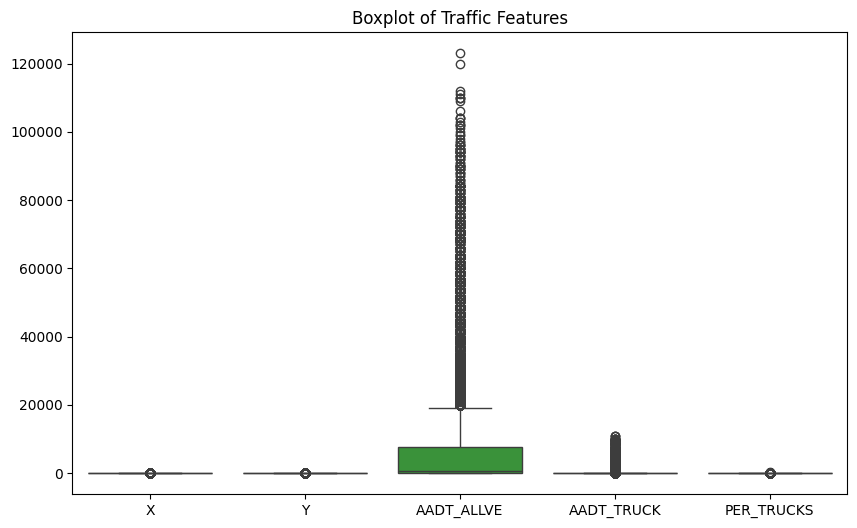

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[['X','Y','AADT_ALLVE','AADT_TRUCK','PER_TRUCKS']])
plt.title("Boxplot of Traffic Features")
plt.show()

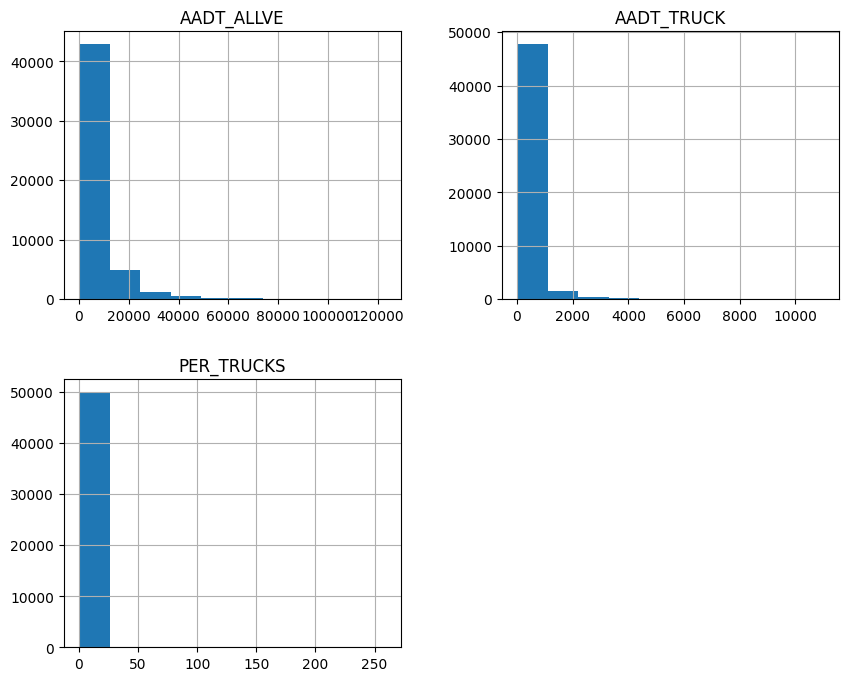

In [43]:
data[['AADT_ALLVE','AADT_TRUCK','PER_TRUCKS']].hist(figsize=(10,8))
plt.show()

## 6. Log Transformation

Traffic volume variables often have highly skewed distributions.
Log transformation is applied to reduce the influence of extreme values.

In [44]:
data['AADT_ALLVE'] = np.log1p(data['AADT_ALLVE'])
data['AADT_TRUCK'] = np.log1p(data['AADT_TRUCK'])

## 7. Feature Scaling

Feature scaling normalizes the dataset so that all features contribute equally
to the machine learning model.

In [45]:
scaler = StandardScaler()

features = ['X','Y','AADT_ALLVE','AADT_TRUCK','PER_TRUCKS']

data[features] = scaler.fit_transform(data[features])

In [46]:
print("Final dataset shape:", data.shape)
data.head()

Final dataset shape: (49949, 5)


,X,Y,AADT_ALLVE,AADT_TRUCK,PER_TRUCKS
0,-0.885597,1.898106,0.971924,1.529991,-0.002330
1,0.487993,-0.185788,0.642007,-0.655201,-0.036784
2,0.031105,-0.164712,1.129167,1.772982,-0.002330
3,-0.038931,-0.123575,1.076548,2.045497,0.049350
4,0.082957,0.159174,1.076548,1.754636,0.006283


## 8. Save Processed Dataset

The cleaned and transformed dataset is saved for machine learning training.

In [ ]:
data.to_csv("../data/processed_traffic_data.csv", index=False)